In [1]:
# Task 1: Supervised Learning - House Price Prediction
# Objective: Predict house prices using labeled data from Kaggle
# Dataset: House Prices - Advanced Regression Techniques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [5]:
print( " House Price Prediction - Supervised Learning Task ")

 House Price Prediction - Supervised Learning Task 


In [6]:
# load dataset

In [8]:
print("Step 1: Loading the dataset")
# Download from Kaggle: House Prices - Advanced Regression Techniques
# Place train.csv in your working directory

Step 1: Loading the dataset


In [12]:
try:
    df = pd.read_csv('train.csv')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
except FileNotFoundError:
    print("Please download 'train.csv' from Kaggle House Prices dataset")
    print("Link: https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data")


Dataset loaded successfully! Shape: (1460, 81)
Columns: 81


In [13]:
# Step 2: Explore the data
print("\nStep 2: Data Exploration...")
print("First few rows:")
print(df.head())


Step 2: Data Exploration...
First few rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  Sal

In [14]:
print(f"\nTarget variable statistics (SalePrice):")
print(df['SalePrice'].describe())


Target variable statistics (SalePrice):
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [15]:
print(f"\nMissing values in dataset:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0].sort_values(ascending=False))



Missing values in dataset:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [16]:
# Step 3: Data preprocessing

In [17]:
print("\nStep 3: Data Preprocessing...")


Step 3: Data Preprocessing...


In [18]:
# Select key features for simplicity (following project guideline: Keep It Simple)
selected_features = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'BedroomAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea'
]

In [19]:
# Create a clean dataset with selected features
df_clean = df[selected_features + ['SalePrice']].copy()

In [20]:
# Handle missing values by filling with median
for column in df_clean.columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column].fillna(df_clean[column].median(), inplace=True)

In [21]:
print(f"Clean dataset shape: {df_clean.shape}")
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Clean dataset shape: (1460, 13)
Missing values after cleaning: 0


In [22]:
# Step 4: Feature selection and target separation
print("\nStep 4: Preparing features and target...")
X = df_clean.drop('SalePrice', axis=1)  # Features
y = df_clean['SalePrice']               # Target variable



Step 4: Preparing features and target...


In [23]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1460, 12)
Target shape: (1460,)


In [24]:
# Step 5: Split the data
print("\nStep 5: Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



Step 5: Splitting data into train and test sets...
Training set: 1168 samples
Test set: 292 samples


In [25]:
# Step 6: Train models
print("\nStep 6: Training machine learning models...")



Step 6: Training machine learning models...


In [26]:
# Model 1: Linear Regression
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

Training Linear Regression...


LinearRegression()

In [27]:
# Model 2: Random Forest (generally performs better)
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training Random Forest...


RandomForestRegressor(random_state=42)

In [28]:
# Step 7: Make predictions
print("\nStep 7: Making predictions...")
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)



Step 7: Making predictions...


In [29]:
# Step 8: Evaluate models
print("\nStep 8: Model Evaluation...")



Step 8: Model Evaluation...


In [30]:
# Step 8: Evaluate models
print("\nStep 8: Model Evaluation...")

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"Mean Absolute Error: ${mae:,.2f}")
    print(f"Root Mean Square Error: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")
    return mae, rmse, r2

lr_metrics = evaluate_model(y_test, lr_pred, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_pred, "Random Forest")


Step 8: Model Evaluation...

Linear Regression Performance:
Mean Absolute Error: $23,270.09
Root Mean Square Error: $37,788.02
R² Score: 0.8138

Random Forest Performance:
Mean Absolute Error: $17,759.36
Root Mean Square Error: $27,913.28
R² Score: 0.8984


In [31]:
# Step 9: Visualize results
print("\nStep 9: Creating visualizations...")
plt.figure(figsize=(15, 5))



Step 9: Creating visualizations...


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Random Forest: Actual vs Predicted Prices')

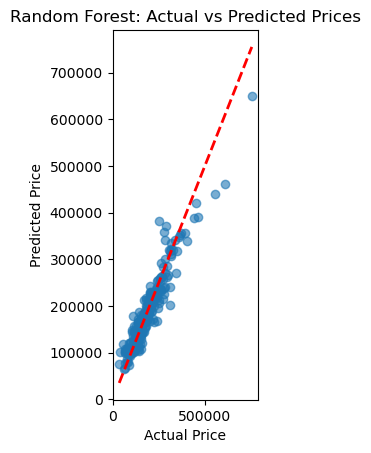

In [34]:
#Plot 1: Actual vs Predicted price
plt.subplot(1, 3, 1)
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Prices')

Text(0.5, 1.0, 'Feature Importance (Random Forest)')

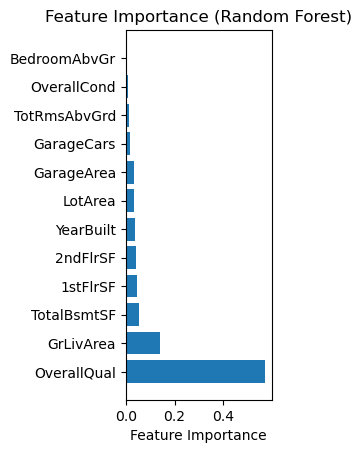

In [36]:
# Plot 2: Feature importance
plt.subplot(1, 3, 2)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)')


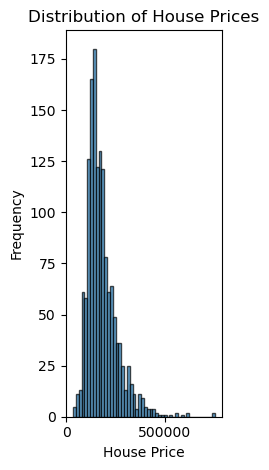

In [37]:
# Plot 3: Price distribution
plt.subplot(1, 3, 3)
plt.hist(y, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')

plt.tight_layout()
plt.show()


In [38]:
# Step 10: Make sample predictions
print("\nStep 10: Sample Predictions...")
print("Making predictions on first 5 test samples:")
sample_predictions = rf_model.predict(X_test.head())
sample_actual = y_test.head()

comparison_df = pd.DataFrame({
    'Actual_Price': sample_actual.values,
    'Predicted_Price': sample_predictions,
    'Difference': sample_actual.values - sample_predictions
})
print(comparison_df)



Step 10: Sample Predictions...
Making predictions on first 5 test samples:
   Actual_Price  Predicted_Price  Difference
0        154500        143066.25    11433.75
1        325000        320090.79     4909.21
2        115000        119586.75    -4586.75
3        159000        160993.50    -1993.50
4        315500        322432.23    -6932.23


In [39]:
# Summary
print("\n" + "="*60)
print("TASK 1 COMPLETED: SUPERVISED LEARNING")
print("="*60)
print(f"✓ Dataset: House Prices from Kaggle")
print(f"✓ Algorithm: Random Forest Regression")
print(f"✓ Best Model R² Score: {rf_metrics[2]:.4f}")
print(f"✓ Mean Absolute Error: ${rf_metrics[0]:,.2f}")
print("✓ Model can predict house prices based on key features")
print("="*60)


TASK 1 COMPLETED: SUPERVISED LEARNING
✓ Dataset: House Prices from Kaggle
✓ Algorithm: Random Forest Regression
✓ Best Model R² Score: 0.8984
✓ Mean Absolute Error: $17,759.36
✓ Model can predict house prices based on key features
